In [13]:
import os
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted, skipping")


Drive already mounted, skipping


In [15]:
import os
print(os.listdir('/content/drive/MyDrive/DL4AI/'))


['extended_data']


In [26]:
import os

# List everything in your DL4AI folder
base = '/content/drive/MyDrive/DL4AI/'
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:3]:  # show first 3 files per folder
        print(f"{indent}  {file}")


/
extended_data/
  PEP.csv
  TMO.csv
  AVGO.csv
data/
  us_market/


In [29]:
PROF_DIR = '/content/drive/MyDrive/DL4AI/extended_data/'   # this is where your data already is
SAVE_DIR = '/content/drive/MyDrive/DL4AI/extended_data/'   # same folder, no need to move anything


In [31]:
import pandas as pd

df_raw = pd.read_csv('/content/drive/MyDrive/DL4AI/extended_data/AAPL.csv')
print("Shape:", df_raw.shape)
print("Columns:", df_raw.columns.tolist())
print(df_raw.head(3))


Shape: (2805, 11)
Columns: ['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', "('Open', 'AAPL')", "('High', 'AAPL')", "('Low', 'AAPL')", "('Close', 'AAPL')", "('Volume', 'AAPL')"]
   Unnamed: 0  Open  High  Low  Close  Volume  ('Open', 'AAPL')  \
0  2015-01-02   NaN   NaN  NaN    NaN     NaN         24.671151   
1  2015-01-05   NaN   NaN  NaN    NaN     NaN         23.984553   
2  2015-01-06   NaN   NaN  NaN    NaN     NaN         23.596952   

   ('High', 'AAPL')  ('Low', 'AAPL')  ('Close', 'AAPL')  ('Volume', 'AAPL')  
0         24.682226        23.776353          24.214893         212818400.0  
1         24.064287        23.346678          23.532724         257142000.0  
2         23.794073        23.173916          23.534937         263188400.0  


In [34]:
def load_stock(ticker, data_dir):
    path = f'{data_dir}{ticker}.csv'
    if not os.path.exists(path):
        print(f"{ticker}: file not found")
        return None

    df = pd.read_csv(path, index_col=0, parse_dates=True)

    # Select only the multi-level columns and rename them
    col_map = {
        f"('Open', '{ticker}')":   'Open',
        f"('High', '{ticker}')":   'High',
        f"('Low', '{ticker}')":    'Low',
        f"('Close', '{ticker}')":  'Close',
        f"('Volume', '{ticker}')": 'Volume',
    }

    # Keep only columns that exist
    existing = {k: v for k, v in col_map.items() if k in df.columns}
    df = df[list(existing.keys())].rename(columns=existing)
    df.dropna(inplace=True)
    return df

# Reload
us_data = {}
for ticker in TICKERS:
    df = load_stock(ticker, DATA_DIR)
    if df is not None and len(df) > 0:
        us_data[ticker] = df
        print(f"{ticker}: {len(df)} rows | {df.index.min().date()} to {df.index.max().date()}")
    else:
        print(f"{ticker}: failed or empty")

print(f"\nLoaded {len(us_data)} tickers")


AAPL: 2805 rows | 2015-01-02 to 2026-02-27
MSFT: 2805 rows | 2015-01-02 to 2026-02-27
GOOGL: 2805 rows | 2015-01-02 to 2026-02-27
AMZN: 2805 rows | 2015-01-02 to 2026-02-27
META: 2805 rows | 2015-01-02 to 2026-02-27
NVDA: 2805 rows | 2015-01-02 to 2026-02-27
TSLA: 2805 rows | 2015-01-02 to 2026-02-27
BRK-B: 2805 rows | 2015-01-02 to 2026-02-27
JPM: 2805 rows | 2015-01-02 to 2026-02-27
JNJ: 2805 rows | 2015-01-02 to 2026-02-27
V: 2805 rows | 2015-01-02 to 2026-02-27
PG: 2805 rows | 2015-01-02 to 2026-02-27
UNH: 2805 rows | 2015-01-02 to 2026-02-27
HD: 2805 rows | 2015-01-02 to 2026-02-27
MA: 2805 rows | 2015-01-02 to 2026-02-27
DIS: 2805 rows | 2015-01-02 to 2026-02-27
PYPL: 2679 rows | 2015-07-06 to 2026-02-27
NFLX: 2805 rows | 2015-01-02 to 2026-02-27
ADBE: 2805 rows | 2015-01-02 to 2026-02-27
CRM: 2805 rows | 2015-01-02 to 2026-02-27
INTC: 2805 rows | 2015-01-02 to 2026-02-27
CSCO: 2805 rows | 2015-01-02 to 2026-02-27
PFE: 2805 rows | 2015-01-02 to 2026-02-27
KO: 2805 rows | 2015-01-

In [51]:
us_data = {}
for ticker in TICKERS:
    path = f'{DATA_DIR}{ticker}.csv'
    if not os.path.exists(path):
        print(f"{ticker}: file not found")
        continue

    df = pd.read_csv(path, index_col=0, parse_dates=True)

    col_map = {
        f"('Open', '{ticker}')":   'Open',
        f"('High', '{ticker}')":   'High',
        f"('Low', '{ticker}')":    'Low',
        f"('Close', '{ticker}')":  'Close',
        f"('Volume', '{ticker}')": 'Volume',
    }
    existing = {k: v for k, v in col_map.items() if k in df.columns}
    df = df[list(existing.keys())].rename(columns=existing)
    df.dropna(inplace=True)

    if len(df) > 0:
        us_data[ticker] = df
        print(f"{ticker}: {len(df)} rows")
    else:
        print(f"{ticker}: empty after loading")

print(f"\nTotal loaded: {len(us_data)} tickers")


AAPL: 2805 rows
MSFT: 2805 rows
GOOGL: 2805 rows
AMZN: 2805 rows
META: 2805 rows
NVDA: 2805 rows
TSLA: 2805 rows
BRK-B: 2805 rows
JPM: 2805 rows
JNJ: 2805 rows
V: 2805 rows
PG: 2805 rows
UNH: 2805 rows
HD: 2805 rows
MA: 2805 rows
DIS: 2805 rows
PYPL: 2679 rows
NFLX: 2805 rows
ADBE: 2805 rows
CRM: 2805 rows
INTC: 2805 rows
CSCO: 2805 rows
PFE: 2805 rows
KO: 2805 rows
PEP: 2805 rows
NKE: 2805 rows
MRK: 2805 rows
ABT: 2805 rows
TMO: 2805 rows
AVGO: 2805 rows
QCOM: 2805 rows
TXN: 2805 rows
AMD: 2805 rows
SBUX: 2805 rows
GILD: 2805 rows
MDLZ: 2805 rows

Total loaded: 36 tickers


In [38]:
def add_financial_features(df):
    df = df.copy()

    # --- Trend indicators ---
    df['SMA_10']  = df['Close'].rolling(10).mean()
    df['SMA_50']  = df['Close'].rolling(50).mean()
    df['EMA_10']  = df['Close'].ewm(span=10, adjust=False).mean()
    df['EMA_50']  = df['Close'].ewm(span=50, adjust=False).mean()

    # --- Momentum ---
    df['Return_1d'] = df['Close'].pct_change(1)
    df['Return_5d'] = df['Close'].pct_change(5)
    df['Return_10d']= df['Close'].pct_change(10)
    df['Momentum']  = df['Close'] - df['Close'].shift(10)

    # --- Volatility ---
    df['Volatility_10'] = df['Return_1d'].rolling(10).std()
    df['Volatility_30'] = df['Return_1d'].rolling(30).std()

    # --- RSI (14-day) ---
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    df['RSI_14'] = 100 - (100 / (1 + rs))

    # --- MACD ---
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD']        = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

    # --- Bollinger Bands ---
    sma20 = df['Close'].rolling(20).mean()
    std20 = df['Close'].rolling(20).std()
    df['BB_upper'] = sma20 + 2 * std20
    df['BB_lower'] = sma20 - 2 * std20
    df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

    # --- Volume indicators ---
    df['Volume_MA10'] = df['Volume'].rolling(10).mean()
    df['Volume_Ratio'] = df['Volume'] / (df['Volume_MA10'] + 1e-9)

    # Drop NaN rows created by rolling windows
    df.dropna(inplace=True)
    return df


In [39]:
FEATURES = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_10', 'SMA_50', 'EMA_10', 'EMA_50',
    'Return_1d', 'Return_5d', 'Return_10d', 'Momentum',
    'Volatility_10', 'Volatility_30',
    'RSI_14', 'MACD', 'MACD_Signal',
    'BB_upper', 'BB_lower', 'BB_width',
    'Volume_MA10', 'Volume_Ratio'
]
TARGET_IDX = 0  # 'Open' is index 0


In [50]:
df_test = add_financial_features(us_data['AAPL'])
print(f"Rows before: {len(us_data['AAPL'])}")
print(f"Rows after:  {len(df_test)}")
print(f"MIN_ROWS:    {MIN_ROWS}")

train, val, test = split_stock(df_test)
print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")


Rows before: 0
Rows after:  0
MIN_ROWS:    110
Train: 0 | Val: 0 | Test: 0


In [40]:
def split_stock(df, train_ratio=0.70, val_ratio=0.15):
    n      = len(df)
    tr_end = int(n * train_ratio)
    va_end = int(n * (train_ratio + val_ratio))

    train = df.iloc[:tr_end]
    val   = df.iloc[tr_end:va_end]
    test  = df.iloc[va_end:]
    return train, val, test


In [52]:
valid_stocks = {}
for ticker, df_raw in us_data.items():
    try:
        df = add_financial_features(df_raw)
        train, val, test = split_stock(df)

        if min(len(train), len(val), len(test)) < MIN_ROWS:
            print(f"{ticker} skipped: too short")
            continue

        valid_stocks[ticker] = {'train': train, 'val': val, 'test': test}

    except Exception as e:
        print(f"{ticker} error: {e}")

print(f"Valid stocks: {len(valid_stocks)}")


Valid stocks: 36


In [42]:
WINDOW     = 60
TARGET_IDX = 0
FEATURES   = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_10', 'SMA_50', 'EMA_10', 'EMA_50',
    'Return_1d', 'Return_5d', 'Return_10d', 'Momentum',
    'Volatility_10', 'Volatility_30',
    'RSI_14', 'MACD', 'MACD_Signal',
    'BB_upper', 'BB_lower', 'BB_width',
    'Volume_MA10', 'Volume_Ratio'
]
DATA_DIR      = '/content/drive/MyDrive/DL4AI/extended_data/'
SAVE_DIR_T11  = '/content/drive/MyDrive/DL4AI/models/task1_1/'
SAVE_DIR_T12  = '/content/drive/MyDrive/DL4AI/models/task1_2/'
SAVE_DIR_T13  = '/content/drive/MyDrive/DL4AI/models/task1_3/'
SAVE_DIR_T2   = '/content/drive/MyDrive/DL4AI/models/task2/'
RESULTS_DIR   = '/content/drive/MyDrive/DL4AI/results/'

import os
for folder in [SAVE_DIR_T11, SAVE_DIR_T12, SAVE_DIR_T13, SAVE_DIR_T2, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"WINDOW={WINDOW} | TARGET={FEATURES[TARGET_IDX]} | Features={len(FEATURES)}")


WINDOW=60 | TARGET=Open | Features=23


In [37]:
# Replace your imports with these — all from tf_keras only
import tensorflow as tf
from tf_keras.models import Model
from tf_keras.layers import LSTM, Dense, Dropout, Input
from tf_keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os
from google.colab import drive


In [ ]:


drive.mount('/content/drive')

WINDOW     = 60
FEATURES   = ['Open', 'High', 'Low', 'Close', 'Volume']
TARGET_IDX = 0
SAVE_DIR   = '/content/drive/MyDrive/DL4AI/models/'
PKL_PATH   = '/content/drive/MyDrive/DL4AI/valid_stocks.pkl'
os.makedirs(SAVE_DIR, exist_ok=True)

if os.path.exists(PKL_PATH):
    with open(PKL_PATH, 'rb') as f:
        valid_stocks = pickle.load(f)
    print(f"Loaded {len(valid_stocks)} stocks from Drive cache")

else:
    print("Cache not found — rebuilding valid_stocks...")

    TICKERS = [
        'AAPL','MSFT','GOOGL','AMZN','META','NVDA','TSLA','BRK-B',
        'JPM','JNJ','V','PG','UNH','HD','MA','DIS','PYPL','NFLX',
        'ADBE','CRM','INTC','CSCO','PFE','KO','PEP','NKE','MRK',
        'ABT','TMO','AVGO','QCOM','TXN','AMD','SBUX','GILD','MDLZ'
    ]

    START, END = '2015-01-01', '2024-01-01'
    MIN_ROWS   = WINDOW + 50

    valid_stocks = {}
    for ticker in TICKERS:
        try:
            df = yf.download(ticker, start=START, end=END,
                             auto_adjust=True, progress=False)[FEATURES]
            df.dropna(inplace=True)

            n      = len(df)
            tr_end = int(n * 0.70)
            va_end = int(n * 0.85)

            train = df.iloc[:tr_end]
            val   = df.iloc[tr_end:va_end]
            test  = df.iloc[va_end:]

            if min(len(train), len(val), len(test)) < MIN_ROWS:
                print(f"  {ticker} skipped (too short)")
                continue

            valid_stocks[ticker] = {'train': train, 'val': val, 'test': test}
            print(f"  {ticker}: {len(train)}/{len(val)}/{len(test)}")

        except Exception as e:
            print(f"  {ticker} error: {e}")

    with open(PKL_PATH, 'wb') as f:
        pickle.dump(valid_stocks, f)
    print(f"Saved {len(valid_stocks)} stocks to {PKL_PATH}")

print(f"Session ready | {len(valid_stocks)} stocks | WINDOW={WINDOW}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 35 stocks from Drive cache
Session ready | 35 stocks | WINDOW=60


In [45]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

def split_and_scale(train, val, test):
    scaler = MinMaxScaler()
    train_s = scaler.fit_transform(train[FEATURES].values)
    val_s   = scaler.transform(val[FEATURES].values)
    test_s  = scaler.transform(test[FEATURES].values)
    return train_s, val_s, test_s, scaler

def create_windows(data, window, k=1, mode='next'):
    X, y = [], []
    for i in range(len(data) - window - k + 1):
        X.append(data[i:i+window])
        if mode == 'next':
            y.append(data[i+window][TARGET_IDX])
        elif mode == 'kth':
            y.append(data[i+window+k-1][TARGET_IDX])
        elif mode == 'multi':
            y.append(data[i+window:i+window+k, TARGET_IDX])
    return np.array(X), np.array(y)

def inverse_target(vals, scaler):
    dummy = np.zeros((len(vals), len(FEATURES)))
    dummy[:, TARGET_IDX] = vals.flatten()
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]

def build_lstm(input_shape, output_size=1):
    inputs  = Input(shape=input_shape)
    x       = LSTM(64, return_sequences=True)(inputs)
    x       = Dropout(0.2)(x)
    x       = LSTM(32)(x)
    x       = Dropout(0.2)(x)
    outputs = Dense(output_size)(x)
    model   = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model




AAPL | X_train: (1869, 60, 23) | X_val: (353, 60, 23) | X_test: (354, 60, 23)
Epoch 1/100
59/59 [==============================] - 9s 71ms/step - loss: 0.0165 - val_loss: 0.0024
Epoch 2/100
59/59 [==============================] - 3s 54ms/step - loss: 0.0043 - val_loss: 0.0035
Epoch 3/100
59/59 [==============================] - 4s 76ms/step - loss: 0.0037 - val_loss: 0.0014
Epoch 4/100
59/59 [==============================] - 3s 56ms/step - loss: 0.0036 - val_loss: 0.0012
Epoch 5/100
59/59 [==============================] - 3s 57ms/step - loss: 0.0029 - val_loss: 0.0042
Epoch 6/100
59/59 [==============================] - 4s 62ms/step - loss: 0.0029 - val_loss: 0.0019
Epoch 7/100
59/59 [==============================] - 4s 70ms/step - loss: 0.0025 - val_loss: 0.0010
Epoch 8/100
59/59 [==============================] - 3s 53ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 9/100
59/59 [==============================] - 3s 57ms/step - loss: 0.0028 - val_loss: 0.0023
Epoch 10/100
59/59 [==

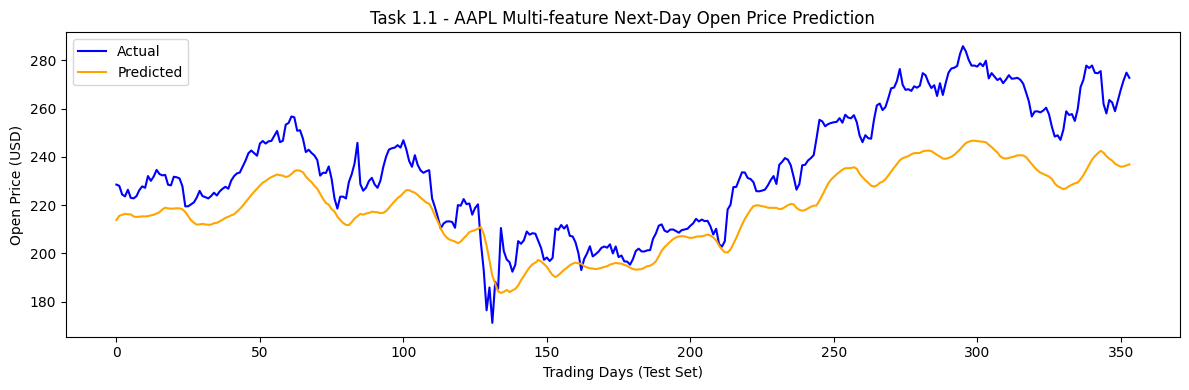

In [53]:
s = valid_stocks['AAPL']
train_s, val_s, test_s, scaler_aapl = split_and_scale(
    s['train'], s['val'], s['test'])

X_tr, y_tr = create_windows(train_s, WINDOW)
X_v,  y_v  = create_windows(val_s,   WINDOW)
X_te, y_te = create_windows(test_s,  WINDOW)
print(f"AAPL | X_train: {X_tr.shape} | X_val: {X_v.shape} | X_test: {X_te.shape}")

model_aapl = build_lstm((WINDOW, len(FEATURES)))
history = model_aapl.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=100, batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

y_pred     = model_aapl.predict(X_te, verbose=0)
y_te_inv   = inverse_target(y_te,   scaler_aapl)
y_pred_inv = inverse_target(y_pred, scaler_aapl)

mae  = mean_absolute_error(y_te_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_te_inv, y_pred_inv))
print(f"Task 1.1 AAPL | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

model_aapl.save(f'{SAVE_DIR_T11}task1_1_lstm_AAPL.keras')
print("Model saved")

plt.figure(figsize=(12,4))
plt.plot(y_te_inv,   label='Actual',    color='blue')
plt.plot(y_pred_inv, label='Predicted', color='orange')
plt.title('Task 1.1 - AAPL Multi-feature Next-Day Open Price Prediction')
plt.xlabel('Trading Days (Test Set)')
plt.ylabel('Open Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()


In [54]:
def evaluate(y_true, y_pred, ticker='', task=''):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mape  = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2    = 1 - ss_res / ss_tot

    # Direction accuracy
    actual_dir = np.diff(y_true) > 0
    pred_dir   = np.diff(y_pred) > 0
    dir_acc    = np.mean(actual_dir == pred_dir) * 100

    print(f"{task} {ticker} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | MAPE: {mape:.2f}% | R2: {r2:.4f} | Dir Acc: {dir_acc:.2f}%")
    return {'ticker': ticker, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2, 'Dir_Acc': dir_acc}


AAPL | X_train: (1524, 60, 5) | X_val: (280, 60, 5) | X_test: (280, 60, 5)
Epoch 1/100
48/48 [==============================] - 8s 75ms/step - loss: 0.0106 - val_loss: 0.0064
Epoch 2/100
48/48 [==============================] - 3s 54ms/step - loss: 0.0024 - val_loss: 0.0075
Epoch 3/100
48/48 [==============================] - 4s 84ms/step - loss: 0.0019 - val_loss: 0.0042
Epoch 4/100
48/48 [==============================] - 3s 65ms/step - loss: 0.0020 - val_loss: 0.0080
Epoch 5/100
48/48 [==============================] - 3s 53ms/step - loss: 0.0020 - val_loss: 0.0089
Epoch 6/100
48/48 [==============================] - 3s 56ms/step - loss: 0.0018 - val_loss: 0.0033
Epoch 7/100
48/48 [==============================] - 3s 53ms/step - loss: 0.0016 - val_loss: 0.0025
Epoch 8/100
48/48 [==============================] - 4s 85ms/step - loss: 0.0018 - val_loss: 0.0067
Epoch 9/100
48/48 [==============================] - 3s 59ms/step - loss: 0.0015 - val_loss: 0.0088
Epoch 10/100
48/48 [=====

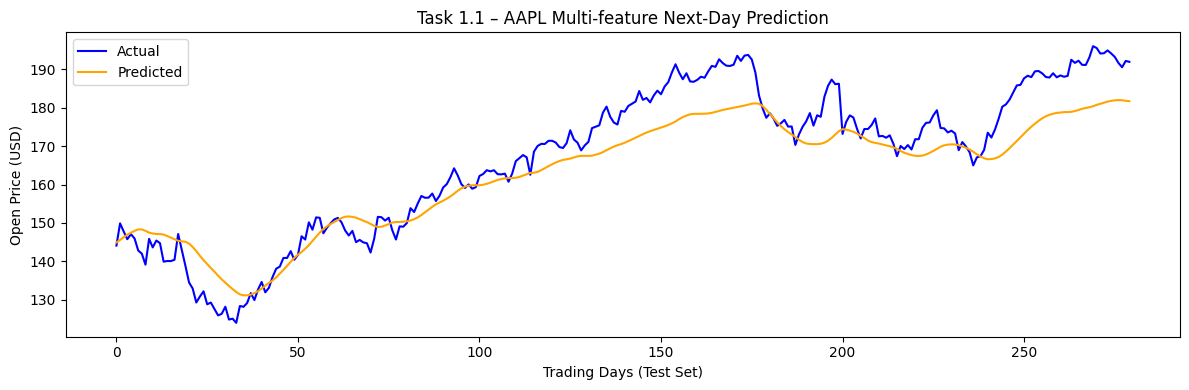

 Model saved to Drive


In [ ]:
# ── Single stock: AAPL ───────────────────────────────
import tensorflow as tf
s = valid_stocks['AAPL']
train_s, val_s, test_s, scaler_aapl = split_and_scale(
    s['train'], s['val'], s['test'])

X_tr, y_tr = create_windows(train_s, WINDOW)
X_v,  y_v  = create_windows(val_s,   WINDOW)
X_te, y_te = create_windows(test_s,  WINDOW)
print(f"AAPL | X_train: {X_tr.shape} | X_val: {X_v.shape} | X_test: {X_te.shape}")

model_aapl = build_lstm((WINDOW, len(FEATURES)))
history = model_aapl.fit(
    X_tr, y_tr,
    validation_data=(X_v, y_v),
    epochs=100, batch_size=32,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

# ── Evaluate ─────────────────────────────────────────
y_pred     = model_aapl.predict(X_te, verbose=0)
y_te_inv   = inverse_target(y_te,   scaler_aapl)
y_pred_inv = inverse_target(y_pred, scaler_aapl)

mae  = mean_absolute_error(y_te_inv, y_pred_inv)
rmse = np.sqrt(mean_squared_error(y_te_inv, y_pred_inv))
print(f"\n Task 1.1 AAPL → MAE: {mae:.4f} | RMSE: {rmse:.4f}")

# ── Plot ─────────────────────────────────────────────
plt.figure(figsize=(12,4))
plt.plot(y_te_inv,   label='Actual',    color='blue')
plt.plot(y_pred_inv, label='Predicted', color='orange')
plt.title('Task 1.1 – AAPL Multi-feature Next-Day Prediction')
plt.xlabel('Trading Days (Test Set)')
plt.ylabel('Open Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

# ── Save model ───────────────────────────────────────
save_dir = '/content/drive/MyDrive/DL4AI/models/'
os.makedirs(save_dir, exist_ok=True)
model_aapl.save(f'{save_dir}task1_1_lstm_aapl.keras')
print(" Model saved to Drive")
